# this is training the CNNPZ model on the noisy mock data with randomly dropping bands

In [1]:
import sys

In [2]:
from packaging import version
import sklearn
from sklearn.model_selection import KFold, train_test_split

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

2026-09-04 03:30:51.310913: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-09-04 03:30:51.310939: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-09-04 03:30:51.312256: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-04 03:30:51.319783: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-04 03:30:54.328498: W tensorflow/compiler/tf2

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [5]:
import pandas as pd
import h5py
import numpy as np

In [6]:
import json
import os

# predefined functions

In [7]:
def rebin_filter(bin_edges, counts, new_edges):
  new_counts = []
  for i in range(len(new_edges) - 1):
      lo, hi = new_edges[i], new_edges[i+1]
      total = 0.0
      for j, (b0, b1, c) in enumerate(
              zip(bin_edges[:-1], bin_edges[1:], counts)):
          overlap = max(0, min(hi, b1) - max(lo, b0))
          total  += c * overlap#/(b1 - b0)  # proportional share
      new_counts.append(total)
  return np.array(new_counts)

def get_bin_edges(centres):
    step = centres[1] - centres[0]          # uniform spacing
    inner_edges = (centres[:-1] + centres[1:]) / 2
    first_edge  = centres[0]  - step / 2
    last_edge   = centres[-1] + step / 2
    return np.concatenate([[first_edge], inner_edges, [last_edge]])

In [8]:
# now write a code to convert all galaxies in the training set into the desired data format:
# array of magnitude
# array of wavelength
# array of filter availability

def convert_data_format(df, lambda_array_cen, no_detect = np.nan, no_obs = np.inf, no_detect_val = 0,
                       no_obs_val = 0):
    # no detection: setting to nan, sensitivity = 1
    # no observation: setting to inf, sensitivity = 0
    num_galaxies = len(df)
    num_wavelength_bins = len(lambda_array_cen)
    
    mags_data = np.zeros((num_galaxies, num_wavelength_bins))
    filter_availability_data = np.zeros((num_galaxies, num_wavelength_bins))
    
    for b in "ugrizy":
        ind = filter_blocks[b].astype(bool)
        mags_data[:, ind] = df[f'mag_{b}_lsst'].to_numpy()[:, None]
        filter_availability_data[:, ind] = 1
    
    for b in "JH":
        ind = filter_blocks[b].astype(bool)
        mags_data[:, ind] = df[f'mag_{b}_roman'].to_numpy()[:, None]
        filter_availability_data[:, ind] = 1
    
    # convert any nan or inf to zero:
    ind_nan = np.isnan(mags_data)
    ind_inf = np.isinf(mags_data)

    if no_obs == np.inf:
        filter_availability_data[ind_inf] = 0
        mags_data[ind_inf] = no_obs_val
        mags_data[ind_nan] = no_detect_val
    elif no_obs == np.nan:
        filter_availability_data[ind_nan] = 0
        mags_data[ind_nan] = no_obs_val
        mags_data[ind_inf] = no_detect_val

    wave_labels = np.arange(num_wavelength_bins)
    # normalize this
    wave_labels = wave_labels/wave_labels[-1]
    
    lambda_labels = np.outer(np.ones(num_galaxies), wave_labels)
    
    transformed_df = [mags_data, lambda_labels, filter_availability_data]
    transformed_df = np.stack(transformed_df, axis=-1)
    
    return transformed_df

In [9]:
#Functions to plot: bias, sigma, outlier fraction:
#Functions to produce these quantities as functin of mag
#from astropy.stats import biweight_location, biweight_scale
from scipy.stats import sigmaclip

def get_biweight_mean_sigma_outlier(subset, nclip= 3, abs_out_thresh=0.2):
    subset_clip, _, _ = sigmaclip(subset, low=3, high=3)
    for _j in range(nclip):
        subset_clip, _, _ = sigmaclip(subset_clip, low=3, high=3)

    #mean = biweight_location(subset_clip)
    #std = biweight_scale(subset_clip)
    mean = np.mean(subset_clip)
    std = np.std(subset_clip)
    #outlier_rate = np.sum(np.abs(subset) > 3 * biweight_scale(subset_clip)) / len(
    #    subset
    #)
    outlier_rate = np.sum(np.abs(subset) > 3 * np.std(subset_clip)) / len(
        subset
    )
    abs_outlier_rate = np.sum(np.abs(subset) > abs_out_thresh) / len(
        subset
    )

    return (
        mean,
        std / np.sqrt(len(subset_clip)),
        std,
        outlier_rate,
        abs_outlier_rate,
    )

In [10]:
import pickle

def get_all_stats(y_train, y_pred, imag_data, save=True, saveroot="", redshift_bins = np.linspace(0,2.5,11), imag_bins = np.linspace(18, 25.5,11)):
    Y = y_train.to_numpy()
    Y2 = y_pred.flatten()
    dz = (Y2 - Y)/(1+Y)
    stats = get_biweight_mean_sigma_outlier(dz, nclip= 3, abs_out_thresh=0.2)

    # split in terms of i-mags and redshifts
    redshift_stats = []
    imag_stats = []
    for i in range(10):
        ind= (Y > redshift_bins[i]) & (Y < redshift_bins[i+1])
        redshift_stats.append(get_biweight_mean_sigma_outlier(dz[ind]))
        ind= (imag_data > imag_bins[i]) & (imag_data < imag_bins[i+1])
        imag_stats.append(get_biweight_mean_sigma_outlier(dz[ind]))

    if save == True:
        with open(saveroot, "wb") as f:
            pickle.dump([stats, redshift_stats, imag_stats], f)

    return stats, redshift_stats, imag_stats

def read_stats(fname):
    with open(fname, "rb") as f:
        data = pickle.load(f)
    stats, redshift_stats, imag_stats = data
    return stats, redshift_stats, imag_stats

In [11]:
import matplotlib.gridspec as gridspec

def plot_stats(stats, redshift_stats, imag_stats, y_train, y_pred, redshift_bins, imag_bins, i_mag_data, save_path=None):
    Y  = y_train.to_numpy()
    Y2 = y_pred.flatten()
    dz = (Y2 - Y) / (1 + Y)

    fig = plt.figure(figsize=(15, 5))   # ← reduced height; 15/3 = 5 per column → square
    gs  = gridspec.GridSpec(
        2, 3,
        figure=fig,
        height_ratios=[2, 1],
        hspace=0.05,
        wspace=0.35
    )
    
    ax_scatter = fig.add_subplot(gs[:, 0])
    ax_zstats  = fig.add_subplot(gs[0, 1])
    ax_zdz     = fig.add_subplot(gs[1, 1], sharex=ax_zstats)
    ax_istats  = fig.add_subplot(gs[0, 2])
    ax_idz     = fig.add_subplot(gs[1, 2], sharex=ax_istats)
    
    # Only scatter panel needs to be square
    ax_scatter.set_box_aspect(1)    # ← only this one

    # ── Panel 1: scatter plot ────────────────────────────────────────────────
    mean, _mean_err, std, outlier_rate, abs_outlier_rate = stats
    mean, std, outlier_rate, abs_outlier_rate = (
        round(mean, 4), round(std, 4),
        round(outlier_rate, 4), round(abs_outlier_rate, 4)
    )

    ax_scatter.scatter(y_train, y_pred, s=0.1, color='k')
    ax_scatter.plot([0, 2.5], [0, 2.5], 'r-')
    ax_scatter.plot([0, 2.5], [0 - 3*std, 2.5 - 3*std], 'r--')
    ax_scatter.plot([0, 2.5], [0 + 3*std, 2.5 + 3*std], 'r--')
    ax_scatter.set_xlim([0, 2.5])
    ax_scatter.set_ylim([0, 2.5])
    ax_scatter.set_xlabel('truth redshift')
    ax_scatter.set_ylabel('predicted redshift')

    abs_out_thresh = 0.2
    label = (
        rf"$\Delta z = {mean}$" + "\n" +
        rf"$\sigma z = {std}$"  + "\n" +
        rf"outlier rate (>3$\sigma$) = {outlier_rate}" + "\n" +
        f"outlier rate (>{abs_out_thresh}) = {abs_outlier_rate}"
    )
    ax_scatter.text(0.1, 1.8, label, fontsize=12)

    # ── Panel 2: redshift statistics ─────────────────────────────────────────
    N_bin  = len(redshift_bins) - 1
    z_mean = np.zeros(N_bin)
    z_err  = np.zeros(N_bin)
    z_std  = np.zeros(N_bin)
    z_out  = np.zeros(N_bin)
    z_abs  = np.zeros(N_bin)
    for i in range(N_bin):
        z_mean[i], z_err[i], z_std[i], z_out[i], z_abs[i] = redshift_stats[i]

    z_centres = (redshift_bins[1:] + redshift_bins[:-1]) / 2
    ax_zstats.plot(z_centres, z_mean, '-', label="bias")
    ax_zstats.plot(z_centres, z_std,  '-', label=r"$\sigma_z$")
    ax_zstats.plot(z_centres, z_out,  '-', label="outlier rate")
    ax_zstats.legend()
    ax_zstats.set_ylabel("statistics")
    plt.setp(ax_zstats.get_xticklabels(), visible=False)

    ax_zdz.scatter(Y, dz, s=0.1, color='k')
    ax_zdz.set_xlabel("redshift")
    ax_zdz.set_ylabel(r"$(z_{pred} - z_{true})/(1 + z_{true})$")
    ax_zdz.set_ylim([-0.5, 0.5])    # ← y-axis limit on lower panel

    # ── Panel 3: i-magnitude statistics ──────────────────────────────────────
    N_bin  = len(imag_bins) - 1
    i_mean = np.zeros(N_bin)
    i_err  = np.zeros(N_bin)
    i_std  = np.zeros(N_bin)
    i_out  = np.zeros(N_bin)
    i_abs  = np.zeros(N_bin)
    for i in range(N_bin):
        i_mean[i], i_err[i], i_std[i], i_out[i], i_abs[i] = imag_stats[i]

    i_centres = (imag_bins[1:] + imag_bins[:-1]) / 2
    ax_istats.plot(i_centres, i_mean, '-', label="bias")
    ax_istats.plot(i_centres, i_std,  '-', label=r"$\sigma_z$")
    ax_istats.plot(i_centres, i_out,  '-', label="outlier rate")
    ax_istats.legend()
    ax_istats.set_ylabel("statistics")
    plt.setp(ax_istats.get_xticklabels(), visible=False)

    ax_idz.scatter(i_mag_data, dz, s=0.1, color='k')
    ax_idz.set_xlabel("i magnitude")
    ax_idz.set_ylabel(r"$(z_{pred} - z_{true})/(1 + z_{true})$")
    ax_idz.set_ylim([-0.5, 0.5])    # ← y-axis limit on lower panel

    plt.suptitle("Photo-z Statistics", fontsize=14)
    plt.tight_layout()
    plt.show()

    # Save if filename provided
    if save_path is not None:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
        print(f"Plot saved to {save_path}")

In [12]:
def stats_to_markdown(stats1_input, stats2_input, labels=("Mean", "Mean err", "Std", "Outlier rate", "Abs outlier rate"), skip_indices=(1,),
                     data_title=("Dataset 1", "Dataset 2")):
    # 0. Filter out skipped indices
    keep = [i for i in range(len(stats1_input)) if i not in skip_indices]
    stats1 = [stats1_input[i] for i in keep]
    stats2 = [stats2_input[i] for i in keep]
    labels = [labels[i] for i in keep]
    
    # 1. Fractional change vs dataset 1
    pct_change = [100 * (s2 - s1) / s1 if s1 != 0 else float('nan')
                  for s1, s2 in zip(stats1, stats2)]
    
    # 3. Build rows, rounded to 3 digits
    rows = []
    for label, s1, s2, pc in zip(labels, stats1, stats2, pct_change):
        rows.append(f"| {label} | {s1:.3g} | {s2:.3g} | {pc:.3g}% |")
    
    # 4. Assemble Markdown
    md = (
        f"| Statistic | {data_title[0]} | {data_title[1]} | % change |\n"
        "|---|---:|---:|---:|\n"
        + "\n".join(rows)
    )
    return md

In [13]:
def compare_binned_stats(redshift_bins, imag_bins, redshift_stats1, imag_stats1, redshift_stats2, imag_stats2):
    fig,axarr=plt.subplots(1, 2,figsize=(10,4))

    xlabels=["redshifts", "i magnitude"]

    for j, bins, stats1, stats2 in zip([0,1], [redshift_bins, imag_bins], 
                                      [redshift_stats1, imag_stats1], [redshift_stats2, imag_stats2]):
        plt.sca(axarr[j])
        N_bin = len(bins) - 1
        xx = (bins[1:] + bins[:-1])/2
        
        mean1 = np.zeros(N_bin)
        std1 = np.zeros(N_bin)
        outlier_rate1 = np.zeros(N_bin)
        for i in range(N_bin):
          mean1[i], _, std1[i], outlier_rate1[i], _ = stats1[i]
    
    
        mean2 = np.zeros(N_bin)
        std2 = np.zeros(N_bin)
        outlier_rate2 = np.zeros(N_bin)
        for i in range(N_bin):
          mean2[i], _, std2[i], outlier_rate2[i], _ = stats2[i]
        
        plt.plot(xx, mean1, '-',label="bias", color="C0")
        plt.plot(xx, std1, '-',label="$\sigma_z$", color="C1")
        plt.plot(xx, outlier_rate1, '-',label="outlier rate", color="C2")

        plt.plot(xx, mean2, '--', color="C0")
        plt.plot(xx, std2, '--', color="C1")
        plt.plot(xx, outlier_rate2, '--', color="C2")
        plt.legend()
        plt.ylabel("statistics")
        plt.xlabel(xlabels[j])
        plt.grid()
    plt.tight_layout()

In [14]:
def stretch(x, c=0.5, k=10):
    """
    x: array of values in [0,1]
    c: center of your typical fluctuation band
    k: stretch strength (try 5-50; higher = more aggressive)
    """
    x = np.asarray(x)
    u = np.where(x >= c, (x - c) / (1 - c), (x - c) / c)  # -> [-1, 1], c -> 0
    stretched = np.arcsinh(k * u) / np.arcsinh(k)          # amplify near u=0
    y = np.where(stretched >= 0, c + stretched * (1 - c), c + stretched * c)
    return np.clip(y, 0, 1)

## Load training and test data, filter curves

In [15]:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "train_100k_noisy_y1_i23.parquet"
training_y1 = pd.read_parquet(fname)
training_y1 = training_y1.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

fname = saveroot + "train_100k_noisy_y10_i25.4.parquet"
training_y10 = pd.read_parquet(fname)
training_y10 = training_y10.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
fname = saveroot + "test_100k_noisy_y1_i23.parquet"
test_y1 = pd.read_parquet(fname)
test_y1 = test_y1.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

fname = saveroot + "test_100k_noisy_y10_i25.4.parquet"
test_y10 = pd.read_parquet(fname)
test_y10 = test_y10.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

In [16]:
training_y1.keys()

Index(['galaxy_id', 'ra', 'dec', 'sedid', 'size', 'Ellipticity_1',
       'Ellipticity_2', 'Roman_Y106', 'Roman_J129', 'Roman_H158', 'Roman_F184',
       'Roman_K213', 'WISE_W1', 'WISE_W2', 'redshift', 'true_redshift',
       't_true_redshift', 'Euclid_Y', 'Euclid_J', 'Euclid_H',
       'Euclid_redshift', 'shift_ra', 'shift_dec', 'Ellipticity1',
       'Ellipticity2', 'Roman_obs_F184', 'Roman_obs_K213',
       'totalHalfLightRadiusArcsec', 'TotalEllipticity', 'mag_u_lsst',
       'mag_u_lsst_err', 'mag_g_lsst', 'mag_g_lsst_err', 'mag_r_lsst',
       'mag_r_lsst_err', 'mag_i_lsst', 'mag_i_lsst_err', 'mag_z_lsst',
       'mag_z_lsst_err', 'mag_y_lsst', 'mag_y_lsst_err', 'major', 'minor',
       'mag_y_euclid_nisp', 'mag_y_euclid_nisp_err', 'mag_j_euclid_nisp',
       'mag_j_euclid_nisp_err', 'mag_h_euclid_nisp', 'mag_h_euclid_nisp_err',
       'Roman_obs_Y106', 'Roman_obs_Y106_err', 'mag_J_roman',
       'Roman_obs_J129_err', 'mag_H_roman', 'Roman_obs_H158_err'],
      dtype='object')

### Transform data, make X_train, Y_train, and test dataset, variants of this dataset

In [17]:
# get the LSST and roman filter curves:
filter_root = "/global/homes/q/qhang/desc/rail_base/src/rail/examples_data/estimation_data/data/FILTER/"

wave = {
    "Y":106,
    "J":129,
    "H":158,
}
lsst_filter_curves = {}
roman_filter_curves = {}
for b in "ugrizy":
  lsst_filter_curves[b] = np.loadtxt(filter_root + f'DC2LSST_{b}.res')

for b in "YJH":
  roman_filter_curves[b] = np.loadtxt(filter_root + f'roman_{b}{wave[b]}.res')

# define the wavelength grid
# to begin with, use blocks rather than filter curves
lambda_min = lsst_filter_curves['u'][:,0].min()
lambda_max = roman_filter_curves['H'][:,0].max()
print(lambda_min,lambda_max)

lambda_array = np.linspace(lambda_min,lambda_max,31)
# now let's conver filter curves to blocks: here let's also ignore the big Y band as it overlaps with the y band

3000.0 18650.0


In [18]:
bin_edges = {}
for b in "ugrizyJH":
  if b not in "JH":
    bin_edges[b] = get_bin_edges(lsst_filter_curves[b][:,0])
  else:
    bin_edges[b] = get_bin_edges(roman_filter_curves[b][:,0])
new_edges = lambda_array

rebinned_filters={}
for b in "ugrizyJH":
  if b not in "JH":
    counts = lsst_filter_curves[b][:,1]
  else:
    counts = roman_filter_curves[b][:,1]
  rebinned_filters[b] = rebin_filter(bin_edges[b], counts, new_edges)

lambda_array_cen = (new_edges[1:] + new_edges[:-1])/2
dlambda = new_edges[1] - new_edges[0]
#for b in "ugrizyJH":
#  plt.plot(lambda_array_cen, rebinned_filters[b],'.-')

# further convert this to blocks:
# let's take 1 when the current filter value is > next filter
filter_blocks={}
bands = "ugrizyJH"
for i, b in enumerate("ugrizyJ"):
  if i>0:
    filter_blocks[b] = (rebinned_filters[b] >= rebinned_filters[bands[i+1]]) & (rebinned_filters[b] > rebinned_filters[bands[i-1]])
  else:
    filter_blocks[b] = (rebinned_filters[b] > rebinned_filters[bands[i+1]])
filter_blocks['H'] = (rebinned_filters['H'] > rebinned_filters['J']) & (rebinned_filters['H'] > rebinned_filters['y'])

In [19]:
def transform_data_to_XY(data, apply_stretch = True, c=0.8, k=20, max_mag = 32):
    data_transformed = convert_data_format(data, lambda_array_cen)
    # now split training and validation set:
    Y = data['redshift']
    X = np.copy(data_transformed)
    X[:,:,0] /= max_mag
    if apply_stretch == True:
        X[:,:,0] = stretch(X[:,:,0], c=c, k=k)
    return X, Y

In [20]:
X_y1, Y_y1 = transform_data_to_XY(training_y1)
X_test_y1, Y_test_y1 = transform_data_to_XY(test_y1)

X_y10, Y_y10 = transform_data_to_XY(training_y10)
X_test_y10, Y_test_y10 = transform_data_to_XY(test_y10)

In [21]:
print(X_y1.shape, Y_y1.shape)

(107189, 30, 3) (107189,)


## Making datasets with missing bands - NIR removal

In [22]:
def make_incomplete_nir_data(data, frac=0.5, sub_val = np.inf):
    subset = data.sample(frac=0.5)
    idx = subset.index
    idx = list(subset.index)
    data_copy = data.copy()
    data_copy.loc[idx, 'mag_J_roman'] = np.inf 
    data_copy.loc[idx, 'mag_H_roman'] = np.inf
    X_misnir, Y_misnir = transform_data_to_XY(data_copy)
    return X_misnir, Y_misnir

In [23]:
# let's construct a dataset where half of the sample do not have NIR measurements:
X_y1_misnir, Y_y1_misnir = make_incomplete_nir_data(training_y1)
X_test_y1_misnir, Y_test_y1_misnir = make_incomplete_nir_data(test_y1)

X_y10_misnir, Y_y10_misnir = make_incomplete_nir_data(training_y10)
X_test_y10_misnir, Y_test_y10_misnir = make_incomplete_nir_data(test_y10)

# visualize the data

In [24]:
def visualize_the_data(X, Y, title="Example data vector"):
    delta_wave = 1/len(lambda_array_cen)
    for i, b in enumerate("ugrizyJH"):
      plt.bar(X[i,:,1] , filter_blocks[b].astype(int), color=f'C{i}', width=delta_wave, alpha=0.2,
             edgecolor='white')
    for i in range(5):
      z = Y[i]
      plt.plot(X[i,:,1], X[i,:,0], label=f"z={round(z,2)}")
      plt.plot(X[i,:,1], X[i,:,2], color='k')
    plt.plot(X[i,:,1], X[i,:,2], color='k', label="sensitivity")
    plt.ylabel("mag (normed)")
    plt.xlabel("wavelength label")
    plt.legend()
    plt.title(title)

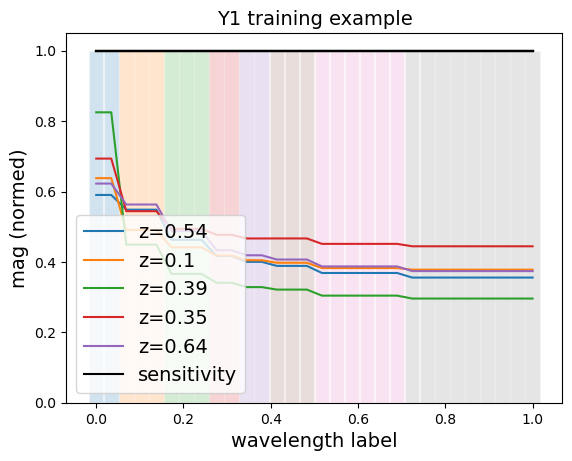

In [26]:
visualize_the_data(X_y1, Y_y1, title="Y1 training example")

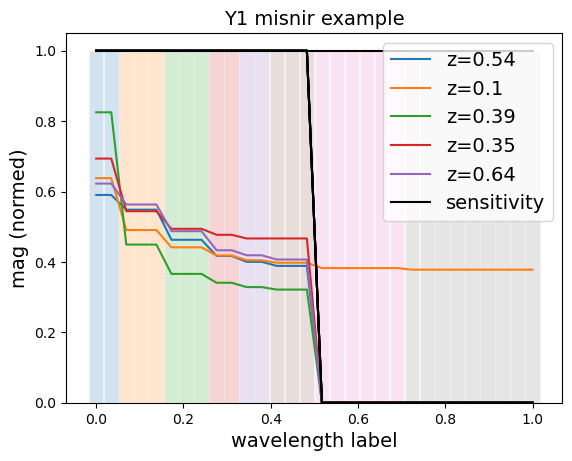

In [27]:
visualize_the_data(X_y1_misnir, Y_y1_misnir, title="Y1 misnir example")

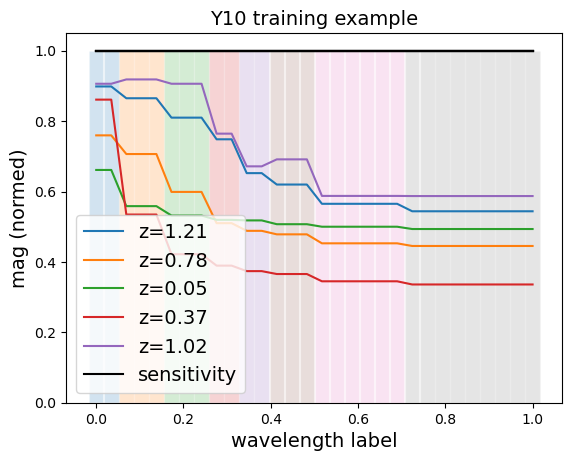

In [28]:
visualize_the_data(X_y10, Y_y10, title="Y10 training example")

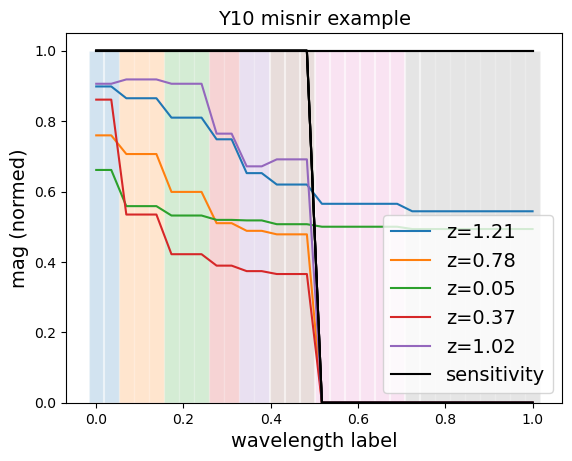

In [29]:
visualize_the_data(X_y10_misnir, Y_y10_misnir, title="Y10 misnir example")

# training ensemble model

In [25]:
# here code up a CNN to with a 1D filter:
from tensorflow.keras import layers, models, callbacks

def build_model(input_shape):
    # 6 layers
    model = models.Sequential([
        layers.Conv1D(32,  kernel_size=3, activation='relu',
                      padding='same', input_shape=input_shape),
        layers.MaxPooling1D(),
        layers.Conv1D(64,  kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(128, kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(256, kernel_size=3, activation='relu',
                      padding='same'),
        #layers.MaxPooling1D(),
        layers.Conv1D(512, kernel_size=3, activation='relu',
                      padding='same'),
        layers.Conv1D(512, kernel_size=3, activation='relu',
                      padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1)
    ])
    return model

def build_model_v2(input_shape):
    # 5 layers
    model = models.Sequential([
        layers.Conv1D(32,  kernel_size=3, activation='relu',
                      padding='same', input_shape=input_shape),
        layers.MaxPooling1D(),
        layers.Conv1D(64,  kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(128, kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(256, kernel_size=3, activation='relu',
                      padding='same'),
        layers.MaxPooling1D(),
        layers.Conv1D(512, kernel_size=3, activation='relu',
                      padding='same'),
        layers.GlobalAveragePooling1D(),
        layers.Dense(64, activation='relu'),
        layers.Dropout(0.3),
        layers.Dense(1)
    ])
    return model

# --- Prediction: average across all models ---
def ensemble_predict(trained_models, X_test):
    predictions = []
    
    for model, Y_mean, Y_std in trained_models:
        # predict in normalised space, then denormalise
        y_pred_norm = model.predict(X_test)
        y_pred = y_pred_norm * Y_std + Y_mean   # denormalise
        predictions.append(y_pred)
    
    # average predictions across all models
    return np.mean(predictions, axis=0), np.std(predictions, axis=0)
    

def plot_ensemble_losses(histories, ylim=(0, 0.1)):
    n_folds = len(histories)
    
    # Define colours and line styles explicitly
    style = {
        'loss':     {'color': 'blue',  'linestyle': '-'},   # solid blue
        'val_loss': {'color': 'blue',  'linestyle': '--'},  # dashed blue
        'mae':      {'color': 'red',   'linestyle': '-'},   # solid red
        'val_mae':  {'color': 'red',   'linestyle': '--'},  # dashed red
    }
    
    # n_folds panels + 1 summary panel
    fig, axes = plt.subplots(
        1, n_folds + 1,
        figsize=(5 * (n_folds + 1), 5),
        sharey=True
    )
    
    # --- Individual fold panels ---
    for fold, (ax, history) in enumerate(zip(axes[:-1], histories)):
        for metric, s in style.items():
            if metric in history.history:
                ax.plot(
                    history.history[metric],
                    label=metric,
                    color=s['color'],
                    linestyle=s['linestyle'],
                    linewidth=2
                )
        ax.set_title(f"Fold {fold+1}")
        ax.set_xlabel("Epoch")
        ax.set_ylim(ylim)
        ax.grid(True)
        ax.legend()
        if fold == 0:
            ax.set_ylabel("Loss / MAE")
    
    # --- Summary panel ---
    ax_summary = axes[-1]
    
    for metric, s in style.items():
        # collect this metric across all folds that have it
        all_folds = [
            h.history[metric]
            for h in histories
            if metric in h.history
        ]
        
        if len(all_folds) == 0:
            continue
        
        # pad to same length (early stopping may stop folds at different epochs)
        max_len = max(len(f) for f in all_folds)
        padded  = [
            np.pad(f, (0, max_len - len(f)), mode='edge')
            for f in all_folds
        ]
        
        mean   = np.mean(padded, axis=0)
        std    = np.std(padded,  axis=0)
        epochs = np.arange(max_len)
        
        # plot mean line
        ax_summary.plot(
            epochs, mean,
            label=metric,
            color=s['color'],
            linestyle=s['linestyle'],
            linewidth=2
        )
        
        # plot shaded std band around mean
        ax_summary.fill_between(
            epochs,
            mean - std,
            mean + std,
            color=s['color'],
            alpha=0.15
        )
    
    ax_summary.set_title("Summary (mean ± std)")
    ax_summary.set_xlabel("Epoch")
    ax_summary.set_ylim(ylim)
    ax_summary.grid(True)
    ax_summary.legend()
    
    plt.suptitle("Ensemble Model — Loss per Fold", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


def save_ensemble(trained_models, save_dir=''):
    """
    Save all ensemble models and their normalisation parameters.
    trained_models: list of (model, Y_mean, Y_std) tuples
    """
    os.makedirs(save_dir, exist_ok=True)
    
    # Save each model separately
    norm_params = []
    for fold, (model, Y_mean, Y_std) in enumerate(trained_models):
        # Save model weights
        model_path = os.path.join(save_dir, f'model_fold_{fold+1}.keras')
        model.save(model_path)
        print(f"Saved fold {fold+1} model to {model_path}")
        
        # Collect normalisation parameters
        norm_params.append({
            'fold':   fold + 1,
            'Y_mean': float(Y_mean),
            'Y_std':  float(Y_std)
        })
    
    # Save normalisation parameters as a single JSON file
    norm_path = os.path.join(save_dir, 'norm_params.json')
    with open(norm_path, 'w') as f:
        json.dump(norm_params, f, indent=2)
    print(f"Saved normalisation parameters to {norm_path}")


def load_ensemble(save_dir=''):
    """
    Load all ensemble models and their normalisation parameters.
    Returns: list of (model, Y_mean, Y_std) tuples
    """
    # Load normalisation parameters
    norm_path = os.path.join(save_dir, 'norm_params.json')
    with open(norm_path, 'r') as f:
        norm_params = json.load(f)
    
    # Load each model
    trained_models = []
    for params in norm_params:
        fold      = params['fold']
        model_path = os.path.join(save_dir, f'model_fold_{fold}.keras')
        
        model  = tf.keras.models.load_model(model_path)
        Y_mean = params['Y_mean']
        Y_std  = params['Y_std']
        
        trained_models.append((model, Y_mean, Y_std))
        print(f"Loaded fold {fold} model from {model_path}")
    
    return trained_models

In [70]:
def train_ensembles(build_model_func, X, Y, N_SPLITS = 5, EPOCHS = 100, BATCH_SIZE = 256, random_state=42):

    kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=random_state)
    
    trained_models = []
    histories = []

    for fold, (idx_train, idx_val) in enumerate(kf.split(X)):
        
        print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")
    
        # Clear session before each fold
        tf.keras.backend.clear_session()
    
        # ── Callbacks ─────────────────────────────────────────────────────────────────
        early_stop = callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
        )
        reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
        )
        
        # Split data using fold indices
        X_train, X_val = X[idx_train], X[idx_val]
        Y_train, Y_val = Y[idx_train], Y[idx_val]
        
        # Normalise Y using train statistics only
        #Y_mean, Y_std = Y_train.mean(), Y_train.std()
        Y_mean = 0
        Y_std = 3
        Y_train_norm = (Y_train - Y_mean) / Y_std
        Y_val_norm   = (Y_val   - Y_mean) / Y_std
        
        # Build fresh model for each fold
        model = build_model_func(input_shape=X_train.shape[1:])
        model.compile(optimizer='adam', loss='mse')
        
        # Train
        history = model.fit(
            X_train, Y_train_norm,
            validation_data=(X_val, Y_val_norm),
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            callbacks=[early_stop, reduce_lr],
            verbose=2
        )
        
        trained_models.append((model, Y_mean, Y_std))  # save model + its normalisation
        histories.append(history)

    return trained_models, histories

In [32]:
# train on Y1 complete 
trained_models, histories = train_ensembles(build_model, X_y1, Y_y1)


--- Fold 1/5 ---


2026-08-20 08:31:57.674663: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38478 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:c1:00.0, compute capability: 8.0


Epoch 1/100


2026-08-20 08:31:59.905807: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8903
2026-08-20 08:32:04.670858: I external/local_xla/xla/service/service.cc:168] XLA service 0x7f8bb59a3c70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-20 08:32:04.670875: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-08-20 08:32:04.696325: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787239924.829464  562559 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


335/335 - 12s - loss: 0.3373 - val_loss: 0.1557 - lr: 0.0010 - 12s/epoch - 37ms/step
Epoch 2/100
335/335 - 1s - loss: 0.1443 - val_loss: 0.0993 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
335/335 - 1s - loss: 0.1111 - val_loss: 0.0761 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
335/335 - 1s - loss: 0.0906 - val_loss: 0.0538 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
335/335 - 1s - loss: 0.0832 - val_loss: 0.0541 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100
335/335 - 1s - loss: 0.0792 - val_loss: 0.0431 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100
335/335 - 1s - loss: 0.0744 - val_loss: 0.0419 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 8/100
335/335 - 1s - loss: 0.0703 - val_loss: 0.0452 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 9/100
335/335 - 1s - loss: 0.0683 - val_loss: 0.0398 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 10/100
335/335 - 1s - loss: 0.0688 - val_loss: 0.0437 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 11/100
335/335 - 1s - loss: 0.0683 - val_loss: 0.0431 - lr: 0.

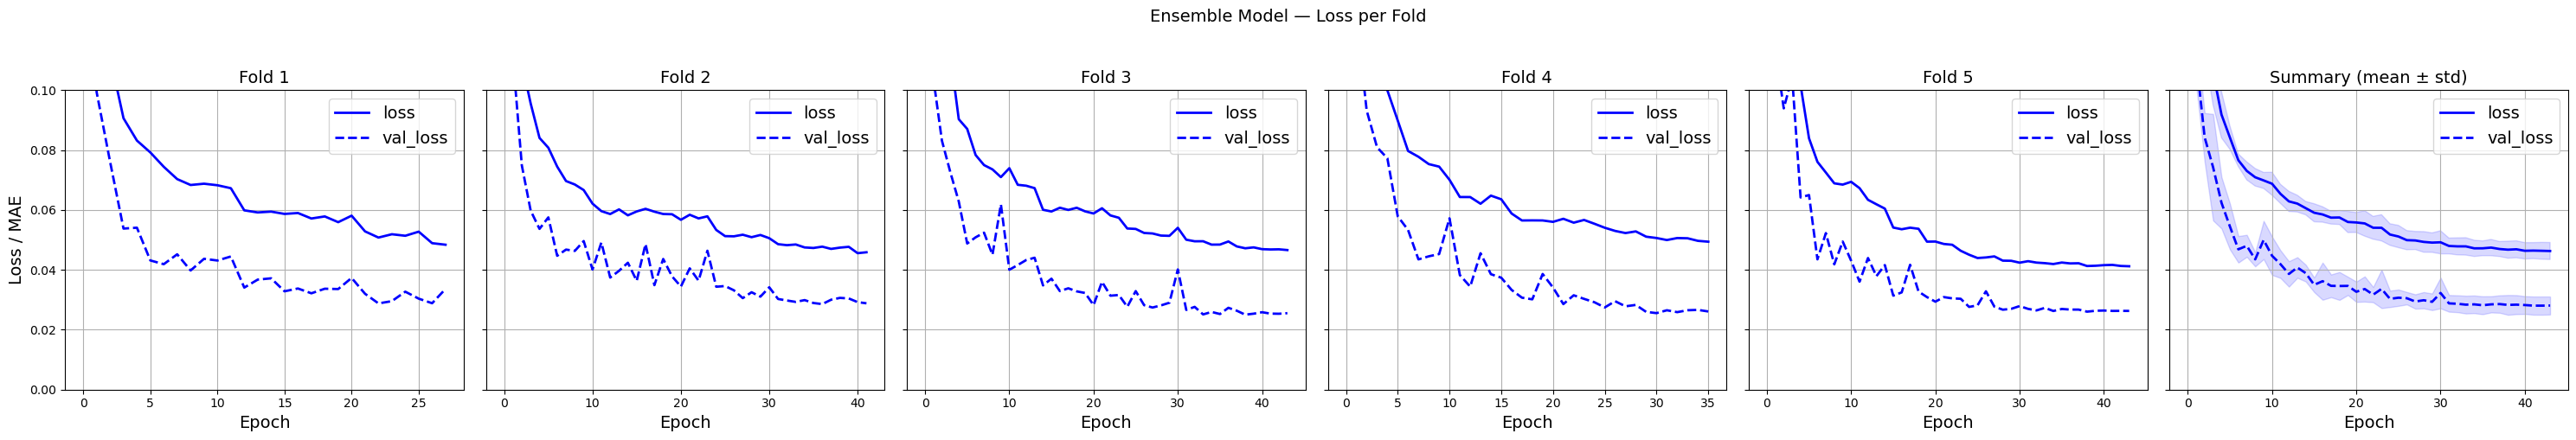

In [33]:
plot_ensemble_losses(histories, ylim=(0, 0.1))

In [34]:
# Final prediction on test set
y_pred_ensemble, y_pred_STD = ensemble_predict(trained_models, X_test_y1)

3360/3360 [==============================] - 4s 1ms/step


In [38]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y1_complete_ensemble_CNN_6layers"
save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/norm_params.json


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

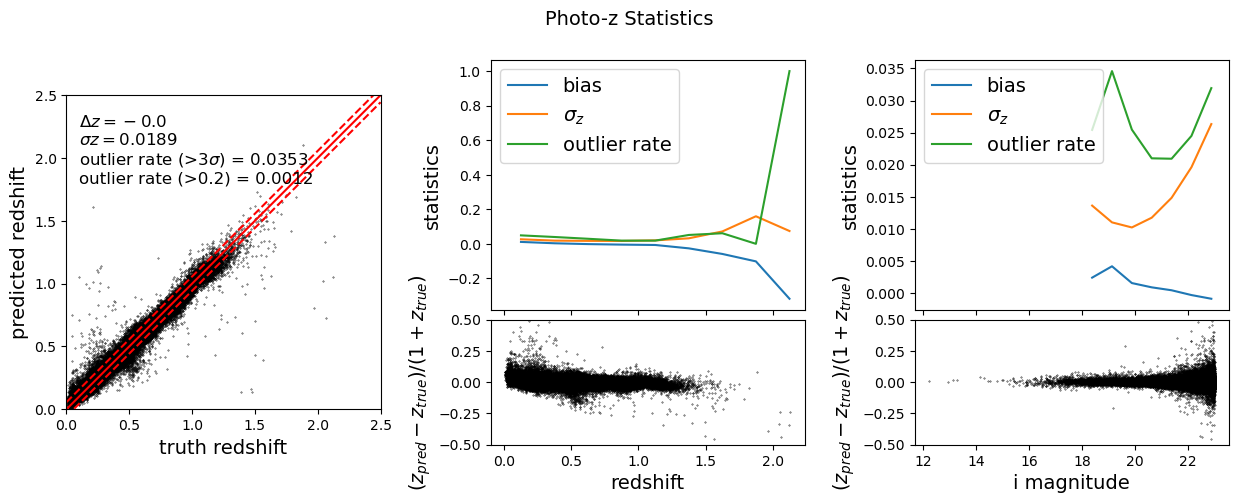

Plot saved to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_complete_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [39]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_test_y1, y_pred_ensemble.flatten(), test_y1['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y1, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, test_y1['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

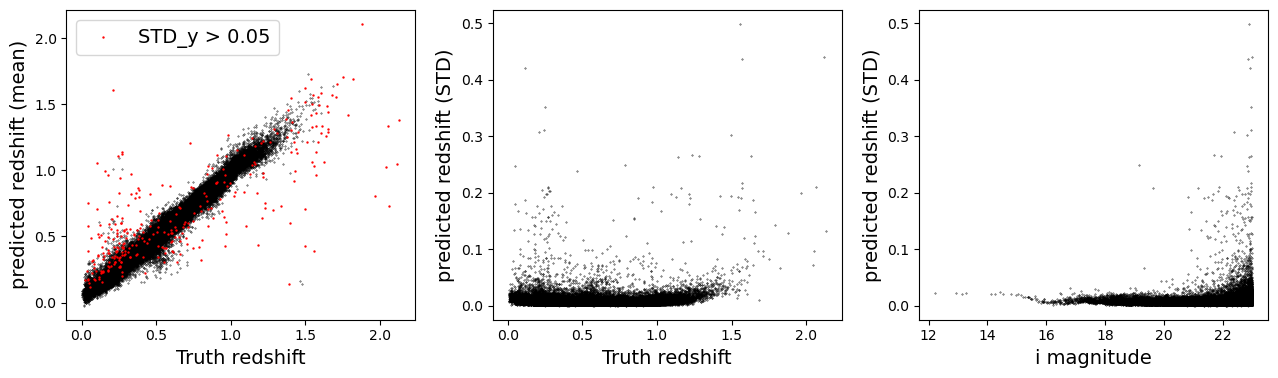

In [41]:
# also plot the STD as a function of redshift and i-band magnitude:
fig,axarr=plt.subplots(1,3,figsize=[13,4])
plt.sca(axarr[0])
ind = y_pred_STD.flatten() >= 0.05
plt.scatter(Y_test_y1[~ind], y_pred_ensemble.flatten()[~ind], s=0.1, color='k')
plt.scatter(Y_test_y1[ind], y_pred_ensemble.flatten()[ind], s=0.5, color='r', label="STD_y > 0.05")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (mean)")
plt.legend()

plt.sca(axarr[1])
plt.scatter(Y_test_y1, y_pred_STD.flatten(), s=0.1, color='k')
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (STD)")

plt.sca(axarr[2])
plt.scatter(test_y1['mag_i_lsst'], y_pred_STD.flatten(), s=0.1, color='k')
plt.xlabel("i magnitude")
plt.ylabel("predicted redshift (STD)")

plt.tight_layout()

In [42]:
# now let's train on the data with dropped bands:
trained_models, histories = train_ensembles(build_model, X_y1_misnir, Y_y1_misnir)


--- Fold 1/5 ---
Epoch 1/100
335/335 - 3s - loss: 0.3426 - val_loss: 0.1691 - lr: 0.0010 - 3s/epoch - 10ms/step
Epoch 2/100
335/335 - 1s - loss: 0.1608 - val_loss: 0.1066 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
335/335 - 1s - loss: 0.1355 - val_loss: 0.0990 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
335/335 - 1s - loss: 0.1208 - val_loss: 0.0912 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
335/335 - 1s - loss: 0.1105 - val_loss: 0.0828 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100
335/335 - 1s - loss: 0.1045 - val_loss: 0.0730 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100
335/335 - 1s - loss: 0.0968 - val_loss: 0.0729 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 8/100
335/335 - 1s - loss: 0.0950 - val_loss: 0.0633 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 9/100
335/335 - 1s - loss: 0.0925 - val_loss: 0.0757 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 10/100
335/335 - 1s - loss: 0.0917 - val_loss: 0.0628 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 11/100
335/335 - 1s - loss: 0.0869

In [43]:
y_pred_ensemble_misnir, y_pred_STD_misnir = ensemble_predict(trained_models, X_test_y1_misnir)

3360/3360 [==============================] - 4s 1ms/step


In [44]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y1_misnir_ensemble_CNN_6layers"
save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/norm_params.json


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

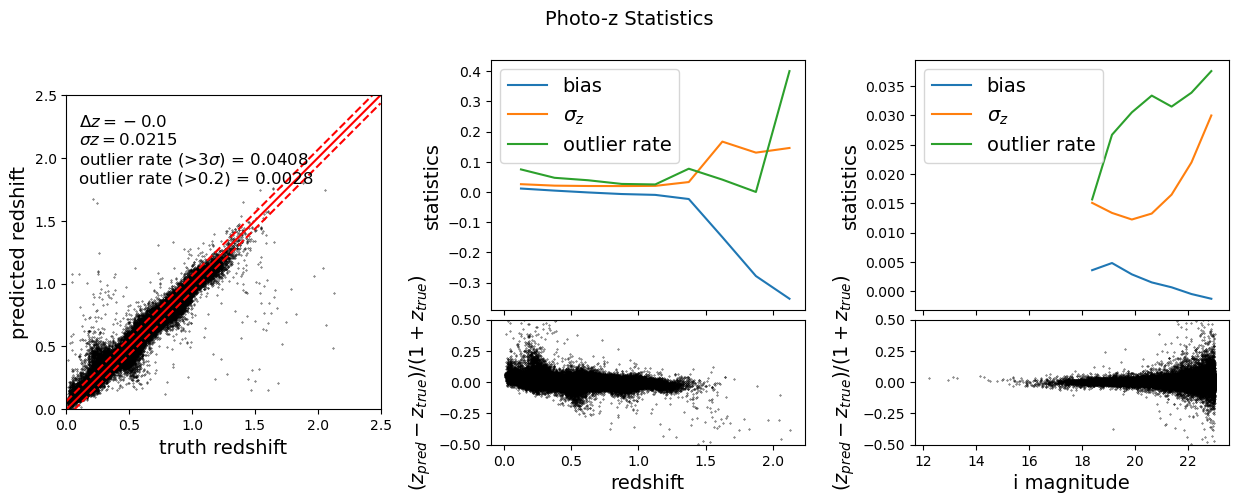

Plot saved to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [45]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_test_y1_misnir, y_pred_ensemble_misnir.flatten(), test_y1['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y1_misnir, y_pred_ensemble_misnir.flatten(), 
           redshift_bins, imag_bins, test_y1['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

In [46]:
# let's apply the complete test data on the model trained with incomplete data
y_pred_ensemble2, y_pred_STD2= ensemble_predict(trained_models, X_test_y1)

3360/3360 [==============================] - 4s 1ms/step


/tmp/ipykernel_562300/2220381783.py:18: RuntimeWarning: invalid value encountered in scalar divide
  outlier_rate = np.sum(np.abs(subset) > 3 * np.std(subset_clip)) / len(
/tmp/ipykernel_562300/2220381783.py:21: RuntimeWarning: invalid value encountered in scalar divide
  abs_outlier_rate = np.sum(np.abs(subset) > abs_out_thresh) / len(
/tmp/ipykernel_562300/1952338895.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


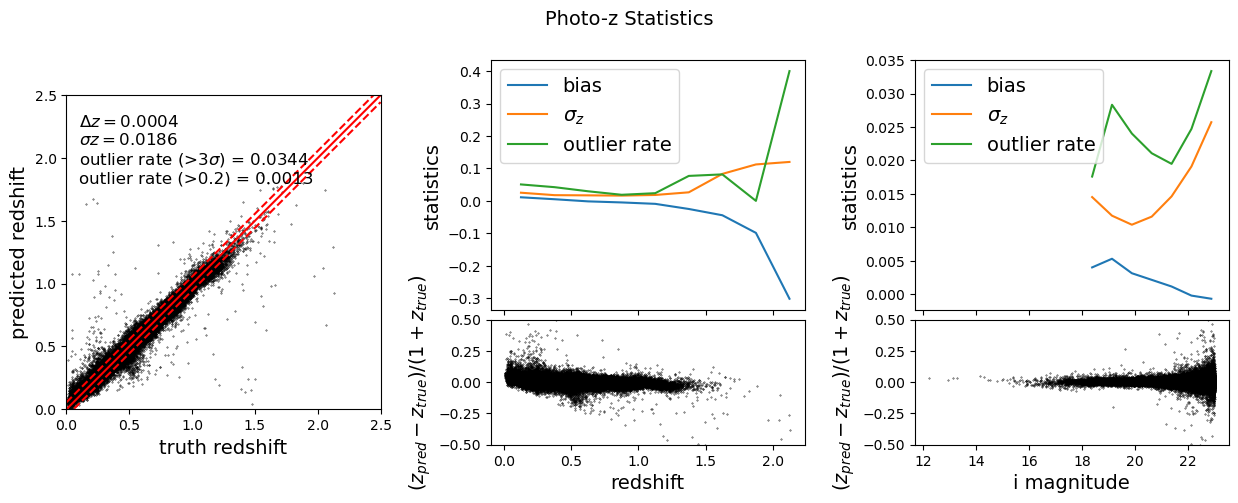

Plot saved to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_misnir_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [47]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_test_y1, y_pred_ensemble2.flatten(), test_y1['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y1, y_pred_ensemble2.flatten(), 
           redshift_bins, imag_bins, test_y1['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

## Cardinal Y10

In [48]:
trained_models, histories = train_ensembles(build_model, X_y10, Y_y10)


--- Fold 1/5 ---
Epoch 1/100
323/323 - 4s - loss: 0.3003 - val_loss: 0.1409 - lr: 0.0010 - 4s/epoch - 12ms/step
Epoch 2/100
323/323 - 1s - loss: 0.1427 - val_loss: 0.0980 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
323/323 - 1s - loss: 0.1267 - val_loss: 0.0879 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
323/323 - 1s - loss: 0.1173 - val_loss: 0.0791 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
323/323 - 1s - loss: 0.1107 - val_loss: 0.0778 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100
323/323 - 1s - loss: 0.1062 - val_loss: 0.0816 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100
323/323 - 1s - loss: 0.1029 - val_loss: 0.0814 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 8/100
323/323 - 1s - loss: 0.1018 - val_loss: 0.0709 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 9/100
323/323 - 1s - loss: 0.0984 - val_loss: 0.0754 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 10/100
323/323 - 1s - loss: 0.0988 - val_loss: 0.0702 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 11/100
323/323 - 1s - loss: 0.0966

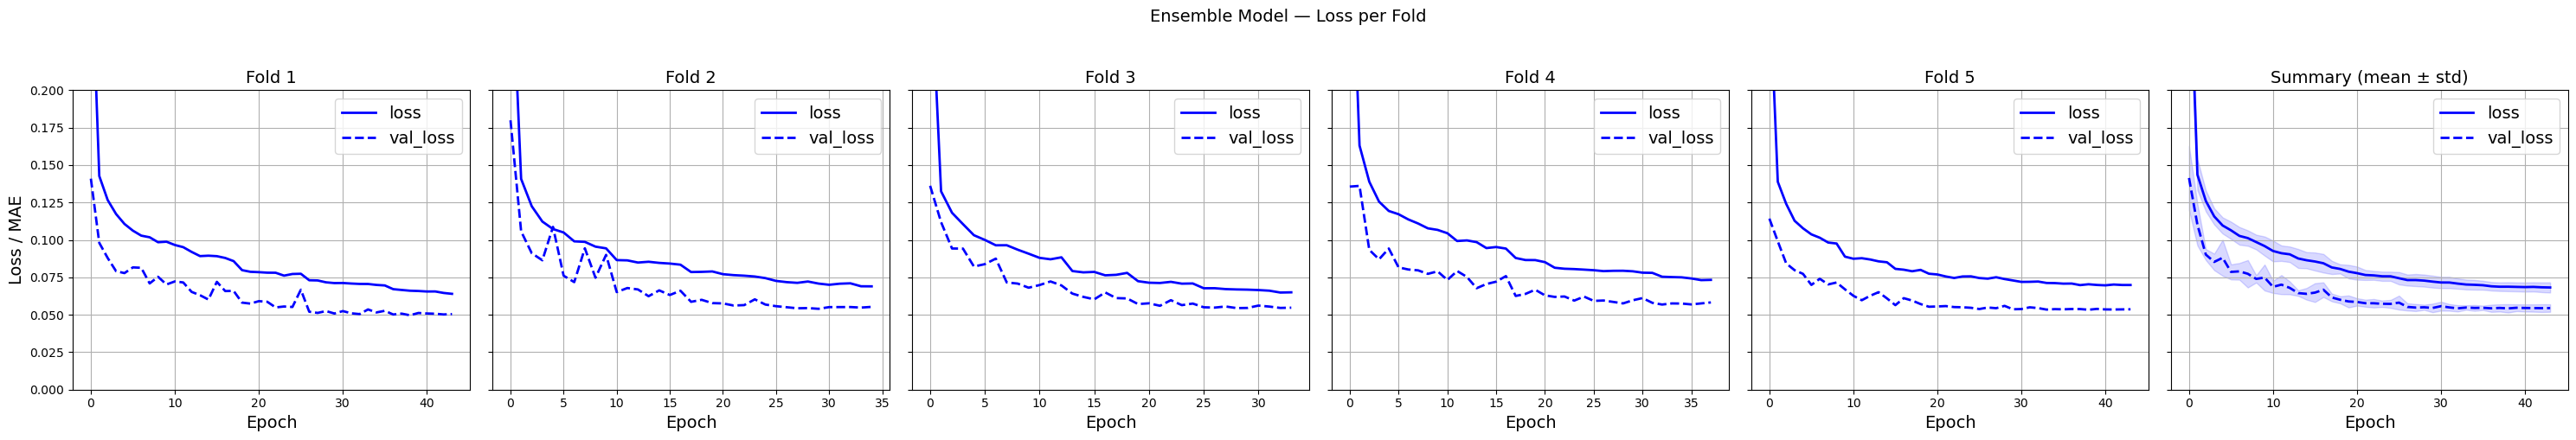

In [50]:
plot_ensemble_losses(histories, ylim=(0, 0.2))

In [51]:
y_pred_ensemble, y_pred_STD = ensemble_predict(trained_models, X_test_y10)

3229/3229 [==============================] - 4s 1ms/step


In [52]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_complete_ensemble_CNN_6layers"
save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/norm_params.json


/tmp/ipykernel_562300/1952338895.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


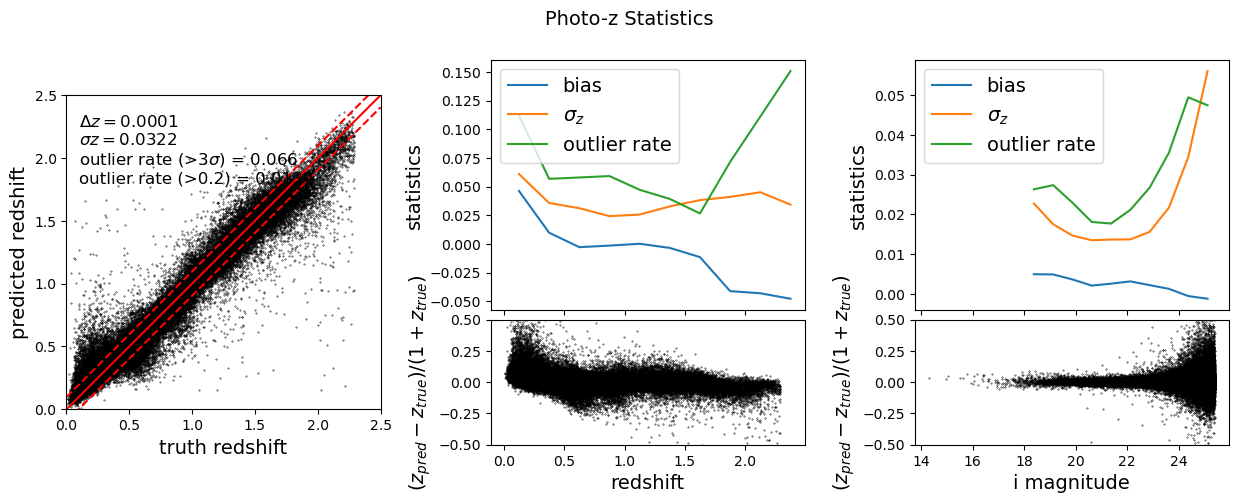

Plot saved to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [53]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_test_y10, y_pred_ensemble.flatten(), test_y10['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y10, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, test_y10['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

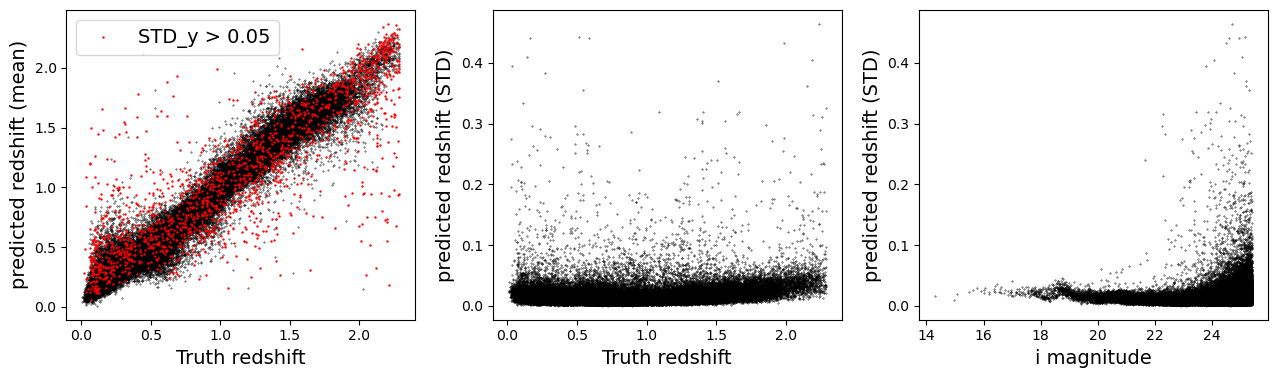

In [54]:
# also plot the STD as a function of redshift and i-band magnitude:
fig,axarr=plt.subplots(1,3,figsize=[13,4])
plt.sca(axarr[0])
ind = y_pred_STD.flatten() >= 0.05
plt.scatter(Y_test_y10[~ind], y_pred_ensemble.flatten()[~ind], s=0.1, color='k')
plt.scatter(Y_test_y10[ind], y_pred_ensemble.flatten()[ind], s=0.5, color='r', label="STD_y > 0.05")
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (mean)")
plt.legend()

plt.sca(axarr[1])
plt.scatter(Y_test_y10, y_pred_STD.flatten(), s=0.1, color='k')
plt.xlabel("Truth redshift")
plt.ylabel("predicted redshift (STD)")

plt.sca(axarr[2])
plt.scatter(test_y10['mag_i_lsst'], y_pred_STD.flatten(), s=0.1, color='k')
plt.xlabel("i magnitude")
plt.ylabel("predicted redshift (STD)")

plt.tight_layout()

In [27]:
# try applying this model to the specsel data: is this consistent?
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_complete_ensemble_CNN_6layers"
trained_models = load_ensemble(save_dir=save_dir)

2026-08-21 03:44:02.932742: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1929] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38478 MB memory:  -> device: 0, name: NVIDIA A100-SXM4-40GB, pci bus id: 0000:82:00.0, compute capability: 8.0


Loaded fold 1 model from /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_1.keras
Loaded fold 2 model from /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_2.keras
Loaded fold 3 model from /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_3.keras
Loaded fold 4 model from /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_4.keras
Loaded fold 5 model from /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/model_fold_5.keras


In [28]:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
training_y10_spec = pd.read_parquet(saveroot + "train_100k_noisy_y10_i25.4.SpecSelect.parquet")
# change the name of the roman columns:
training_y10_spec = training_y10_spec.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

X_y10_spec, Y_y10_spec = transform_data_to_XY(training_y10_spec)
y_pred_ensemble_spec, y_pred_STD_spec = ensemble_predict(trained_models, X_y10_spec)

2026-08-21 03:48:19.299102: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:454] Loaded cuDNN version 8903


3125/3125 [==============================] - 3s 1ms/step


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

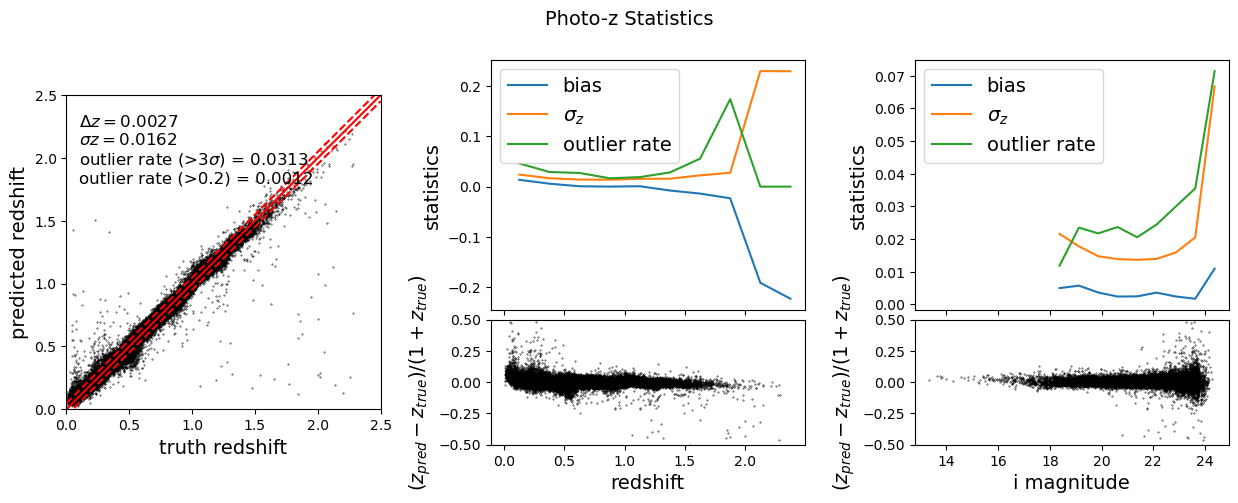

Plot saved to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_complete_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [29]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_y10_spec, y_pred_ensemble_spec.flatten(), 
                                                     training_y10_spec['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

plot_stats(stats2, redshift_stats2, imag_stats2, Y_y10_spec, y_pred_ensemble_spec.flatten(), 
           redshift_bins, imag_bins, training_y10_spec['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

This works well on the spec selected sample!

## dropping nir data

In [55]:
trained_models, histories = train_ensembles(build_model, X_y10_misnir, Y_y10_misnir)


--- Fold 1/5 ---
Epoch 1/100
323/323 - 3s - loss: 0.4370 - val_loss: 0.2732 - lr: 0.0010 - 3s/epoch - 9ms/step
Epoch 2/100
323/323 - 1s - loss: 0.2642 - val_loss: 0.2231 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
323/323 - 1s - loss: 0.2498 - val_loss: 0.2351 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
323/323 - 1s - loss: 0.2349 - val_loss: 0.2176 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
323/323 - 1s - loss: 0.2302 - val_loss: 0.1960 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100
323/323 - 1s - loss: 0.2274 - val_loss: 0.1955 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100
323/323 - 1s - loss: 0.2175 - val_loss: 0.2028 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 8/100
323/323 - 1s - loss: 0.2190 - val_loss: 0.1913 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 9/100
323/323 - 1s - loss: 0.2123 - val_loss: 0.1889 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 10/100
323/323 - 1s - loss: 0.2102 - val_loss: 0.2024 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 11/100
323/323 - 1s - loss: 0.2066 

In [56]:
y_pred_ensemble_misnir, y_pred_STD_misnir = ensemble_predict(trained_models, X_test_y10_misnir)

3229/3229 [==============================] - 3s 1ms/step


In [57]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_misnir_ensemble_CNN_6layers"
save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/norm_params.json


/tmp/ipykernel_562300/1952338895.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


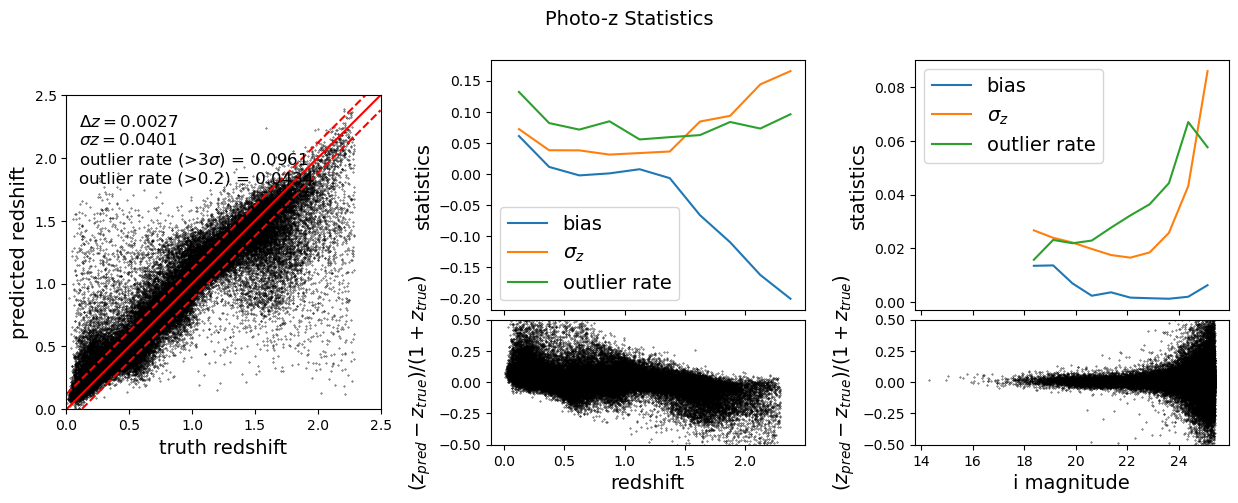

Plot saved to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_misnir_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [58]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_test_y10_misnir, y_pred_ensemble_misnir.flatten(), test_y10['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y10_misnir, y_pred_ensemble_misnir.flatten(), 
           redshift_bins, imag_bins, test_y10['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

## Spec select sample (no pre-training):

In [41]:
saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
training_y10_spec = pd.read_parquet(saveroot + "train_100k_noisy_y10_i25.4.SpecSelect.parquet")
# change the name of the roman columns:
training_y10_spec = training_y10_spec.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})
training_y10_spec = training_y10_spec.reset_index(drop=True) 
X_y10_spec, Y_y10_spec = transform_data_to_XY(training_y10_spec)


saveroot = "/pscratch/sd/q/qhang/cnnpz/cardinal/"
training_y1_spec = pd.read_parquet(saveroot + "train_100k_noisy_y1_i23.SpecSelect.parquet")
# change the name of the roman columns:
training_y1_spec = training_y1_spec.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})
training_y1_spec = training_y1_spec.reset_index(drop=True) 
X_y1_spec, Y_y1_spec = transform_data_to_XY(training_y1_spec)

In [42]:
Y_y1_spec

0        0.540908
1        0.101199
2        0.388574
3        0.346534
4        0.643569
           ...   
90611    0.153747
90612    0.179227
90613    0.666857
90614    0.944296
90615    0.903384
Name: redshift, Length: 90616, dtype: float64

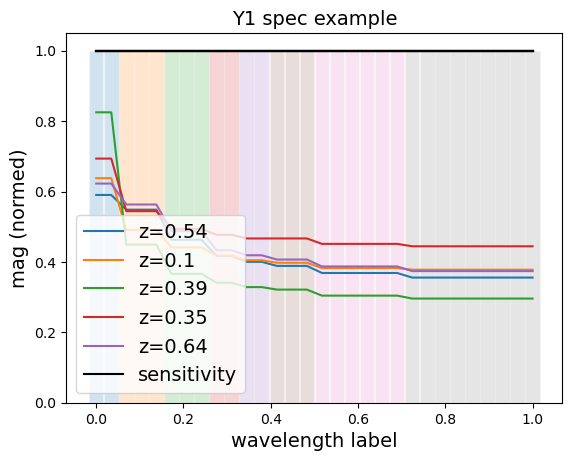

In [32]:
visualize_the_data(X_y1_spec, Y_y1_spec, title="Y1 spec example")

In [43]:
trained_models, histories = train_ensembles(build_model, X_y1_spec, Y_y1_spec)


--- Fold 1/5 ---
Epoch 1/100


2026-08-21 04:25:32.854769: I external/local_xla/xla/service/service.cc:168] XLA service 0x56422fd7bda0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-08-21 04:25:32.854787: I external/local_xla/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA A100-SXM4-40GB, Compute Capability 8.0
2026-08-21 04:25:32.863268: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
I0000 00:00:1787311532.967001 1277334 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


284/284 - 7s - loss: 0.4078 - val_loss: 0.1725 - lr: 0.0010 - 7s/epoch - 24ms/step
Epoch 2/100
284/284 - 1s - loss: 0.1725 - val_loss: 0.1144 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
284/284 - 1s - loss: 0.1408 - val_loss: 0.3193 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
284/284 - 1s - loss: 0.1226 - val_loss: 0.1070 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
284/284 - 1s - loss: 0.0992 - val_loss: 0.0633 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100
284/284 - 1s - loss: 0.0884 - val_loss: 0.0796 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100
284/284 - 1s - loss: 0.0796 - val_loss: 0.0679 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 8/100
284/284 - 1s - loss: 0.0809 - val_loss: 0.0524 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 9/100
284/284 - 1s - loss: 0.0777 - val_loss: 0.0546 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 10/100
284/284 - 1s - loss: 0.0760 - val_loss: 0.0674 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 11/100

Epoch 11: ReduceLROnPlateau reducing learning rate to 0.

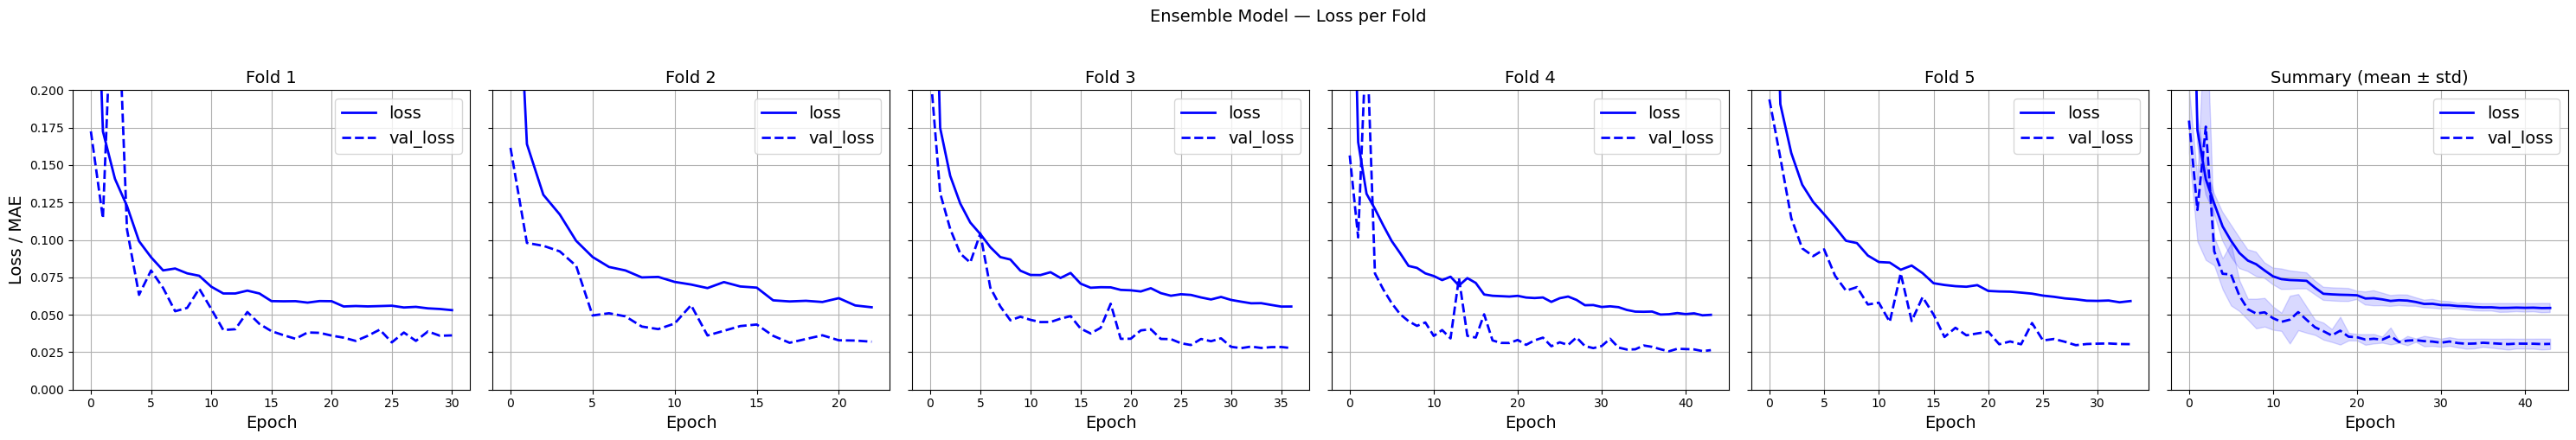

In [44]:
plot_ensemble_losses(histories, ylim=(0, 0.2))

In [45]:
y_pred_ensemble, y_pred_STD = ensemble_predict(trained_models, X_test_y1)

3360/3360 [==============================] - 4s 1ms/step


In [46]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y1_specsel_ensemble_CNN_6layers"
save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/norm_params.json


/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:206: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:163: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:198: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/scipy/stats/_stats_py.py:3666: RuntimeWarning: Mean of empty slice.
  c_mean = c.mean()
/global/common/software/nersc9/tensorflow/2.15.0/lib/python3.9/site-packages/numpy/core/_methods.py:129: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/global

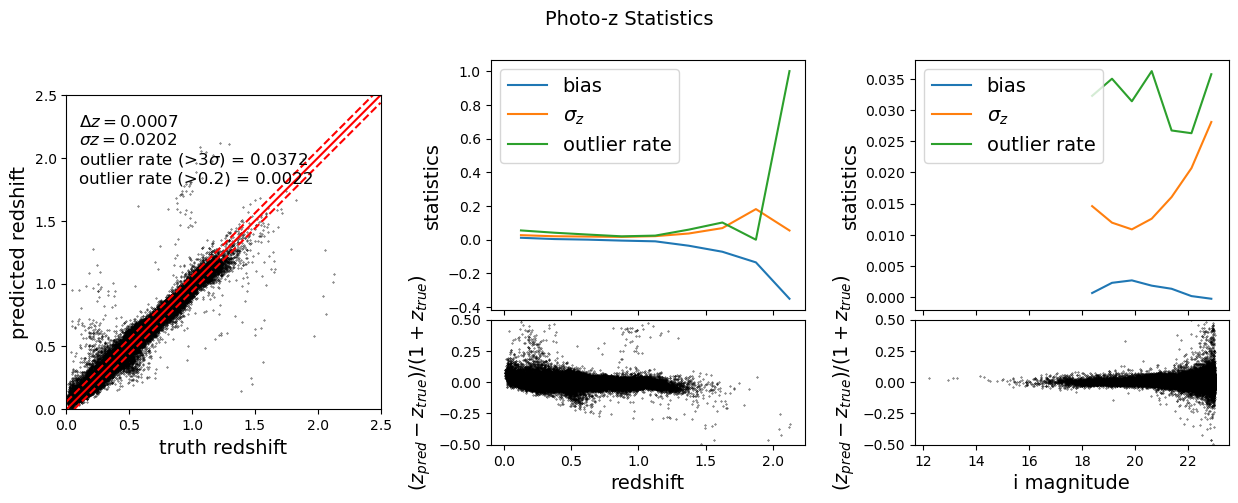

Plot saved to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y1_specsel_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [47]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_test_y1, y_pred_ensemble.flatten(), test_y1['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y1, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, test_y1['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

### Y10

In [48]:
trained_models, histories = train_ensembles(build_model, X_y10_spec, Y_y10_spec)


--- Fold 1/5 ---
Epoch 1/100
313/313 - 4s - loss: 0.3736 - val_loss: 0.1489 - lr: 0.0010 - 4s/epoch - 12ms/step
Epoch 2/100
313/313 - 1s - loss: 0.1413 - val_loss: 0.0813 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 3/100
313/313 - 1s - loss: 0.0956 - val_loss: 0.0553 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 4/100
313/313 - 1s - loss: 0.0827 - val_loss: 0.0529 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 5/100
313/313 - 1s - loss: 0.0715 - val_loss: 0.0533 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 6/100
313/313 - 1s - loss: 0.0706 - val_loss: 0.0363 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 7/100
313/313 - 1s - loss: 0.0685 - val_loss: 0.0422 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 8/100
313/313 - 1s - loss: 0.0653 - val_loss: 0.0503 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 9/100

Epoch 9: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
313/313 - 1s - loss: 0.0665 - val_loss: 0.0430 - lr: 0.0010 - 1s/epoch - 4ms/step
Epoch 10/100
313/313 - 1s - loss: 0.0572 - val_loss: 0.028

In [49]:
y_pred_ensemble, y_pred_STD = ensemble_predict(trained_models, X_test_y10)

3229/3229 [==============================] - 4s 1ms/step


In [50]:
# save the trained model:
root = "/pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models"
save_dir = root + "/y10_specsel_ensemble_CNN_6layers"
save_ensemble(trained_models, save_dir=save_dir)

Saved fold 1 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_1.keras
Saved fold 2 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_2.keras
Saved fold 3 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_3.keras
Saved fold 4 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_4.keras
Saved fold 5 model to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/model_fold_5.keras
Saved normalisation parameters to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/norm_params.json


/tmp/ipykernel_1275168/1952338895.py:98: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


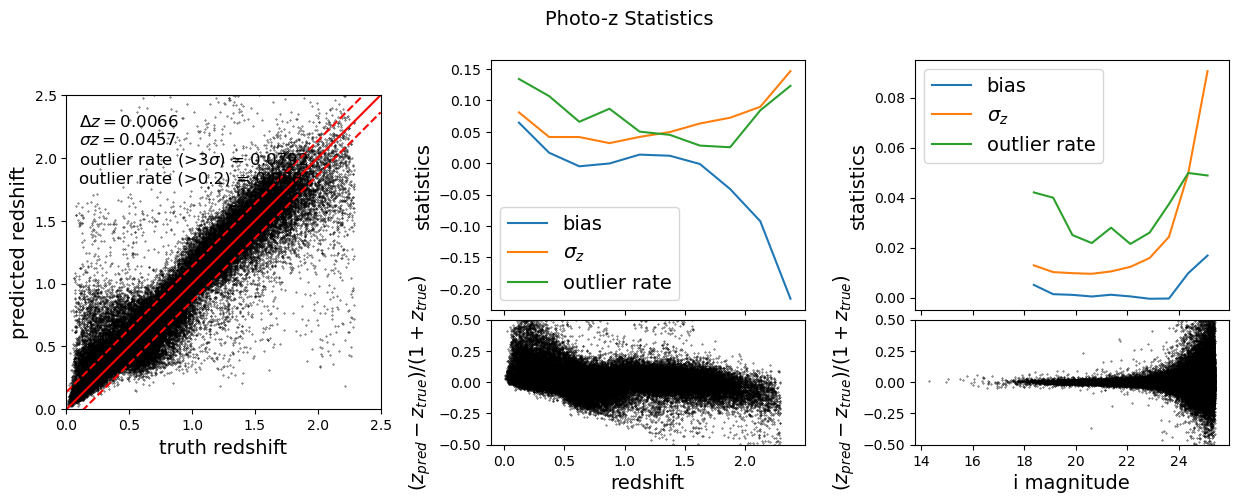

Plot saved to /pscratch/sd/q/qhang/cnnpz/noisy_Cardinal/models/y10_specsel_ensemble_CNN_6layers/photoz_stats.png


<Figure size 640x480 with 0 Axes>

In [51]:
redshift_bins = np.linspace(0,2.5,11)
imag_bins = np.linspace(18, 25.5,11)
#fname = save_dir + "/stats.pkl"
stats2, redshift_stats2, imag_stats2 = get_all_stats(Y_test_y10, y_pred_ensemble.flatten(), test_y10['mag_i_lsst'], save=False, 
                                                     redshift_bins = redshift_bins, imag_bins = imag_bins)

plot_stats(stats2, redshift_stats2, imag_stats2, Y_test_y10, y_pred_ensemble.flatten(), 
           redshift_bins, imag_bins, test_y10['mag_i_lsst'], save_path=save_dir + '/photoz_stats.png')

## Now include pre-training with the pop-cosmos data

In [53]:
# load pre-training data
fname = "/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y1.parquet"
pretraining_y1 = pd.read_parquet(fname)
# change the name of the roman columns:
pretraining_y1 = pretraining_y1.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

fname = "/pscratch/sd/q/qhang/pop-cosmos-data/mock_catalog_Ch1_26.degrade_lsst_y10.parquet"
pretraining_y10 = pd.read_parquet(fname)
# change the name of the roman columns:
pretraining_y10 = pretraining_y10.rename(columns={'Roman_obs_J129': 'mag_J_roman', 
                                              'Roman_obs_H158': 'mag_H_roman'})

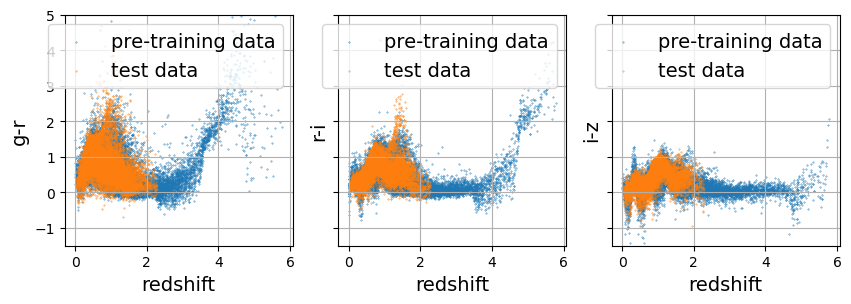

In [65]:
# plot comparison in colour-redshift space:
fig,axarr=plt.subplots(1,3,figsize=[10,3],sharey=True)

for ii, colours in enumerate(['gr','ri','iz']):
    plt.sca(axarr[ii])
    ri = pretraining_y10[f'mag_{colours[0]}_lsst'] - pretraining_y10[f'mag_{colours[1]}_lsst']
    red = pretraining_y10['redshift']
    ind = pretraining_y10['mag_i_lsst'] < 25.4
    plt.scatter(red[ind][::50], ri[ind][::50], s=0.1, label="pre-training data")
    
    ri = training_y10[f'mag_{colours[0]}_lsst'] - training_y10[f'mag_{colours[1]}_lsst']
    red = training_y10['redshift']
    plt.scatter(red[::10], ri[::10], s=0.1, label="test data")
    
    plt.grid()
    plt.legend()
    plt.xlabel("redshift")
    plt.ylabel(f"{colours[0]}-{colours[1]}")
    plt.ylim([-1.5,5])

In [72]:
# pre-training data:
pretraining_y10 = pretraining_y10[pretraining_y10['redshift']<2.4]
pretraining_y10 = pretraining_y10.sample(frac=0.5)
pretraining_y10 = pretraining_y10.reset_index(drop=True)
X_y10_pre, Y_y10_pre = transform_data_to_XY(pretraining_y10)

In [73]:
len(Y_y10_pre)

452012

In [74]:
trained_models, histories = train_ensembles(build_model, X_y10_pre, Y_y10_pre)


--- Fold 1/5 ---
Epoch 1/100
1413/1413 - 7s - loss: 0.0100 - val_loss: 0.0029 - lr: 0.0010 - 7s/epoch - 5ms/step
Epoch 2/100
1413/1413 - 5s - loss: 0.0035 - val_loss: 0.0023 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 3/100
1413/1413 - 5s - loss: 0.0031 - val_loss: 0.0023 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 4/100
1413/1413 - 5s - loss: 0.0029 - val_loss: 0.0018 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 5/100
1413/1413 - 5s - loss: 0.0027 - val_loss: 0.0023 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 6/100
1413/1413 - 5s - loss: 0.0026 - val_loss: 0.0019 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 7/100

Epoch 7: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
1413/1413 - 5s - loss: 0.0026 - val_loss: 0.0019 - lr: 0.0010 - 5s/epoch - 4ms/step
Epoch 8/100
1413/1413 - 5s - loss: 0.0023 - val_loss: 0.0015 - lr: 5.0000e-04 - 5s/epoch - 4ms/step
Epoch 9/100
1413/1413 - 5s - loss: 0.0022 - val_loss: 0.0015 - lr: 5.0000e-04 - 5s/epoch - 4ms/step
Epoch 10/100
1413/1413 - 5s - los

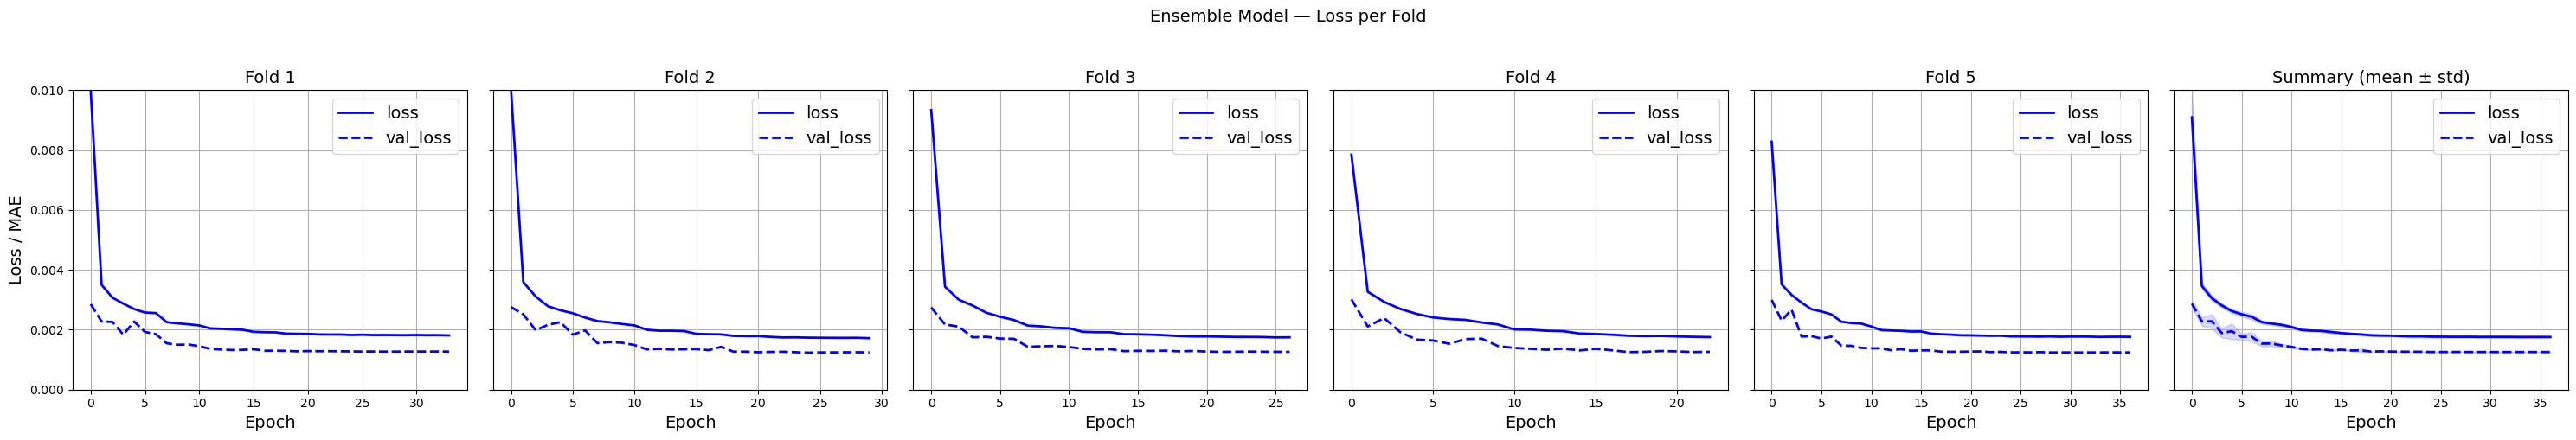

In [77]:
plot_ensemble_losses(histories, ylim=(0, 0.01))

In [84]:
# then fine tune:
def fine_tune_pre_trained_model(X_fortrain, Y_fortrain, pretrained_models = None, model_root = "", nlayers_forzen = 4):

    # need to provide either the model or the model_dir to load the model
    # will always load model if both are provided

    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    
    trained_models = []
    histories = []
    
    for fold, (idx_train, idx_val) in enumerate(kf.split(X_fortrain)):
    
        print(f"\n--- Fold {fold+1}/5 ---")
        tf.keras.backend.clear_session()
        
        # ── Callbacks ─────────────────────────────────────────────────────────────────
        early_stop = callbacks.EarlyStopping(
        monitor='val_loss', patience=5, restore_best_weights=True
        )
        reduce_lr = callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1
        )
        
        # Split data using fold indices
        X_train, X_val = X_fortrain[idx_train], X_fortrain[idx_val]
        Y_train, Y_val = Y_fortrain[idx_train], Y_fortrain[idx_val]

        if model_root != "":
            model = tf.keras.models.load_model(model_root + f'model_fold_{fold+1}.keras')
        else:
            model = pretrained_models[fold][0]
        
        # Step 2: optionally freeze early layers (keep low-level features fixed)
        for layer in model.layers[:nlayers_forzen]:     # freeze first 4 layers
            layer.trainable = False
    
        # same normalization as the pre-training
        Y_mean = 0
        Y_std = 3
        # Normalise Y using train statistics only
        Y_mean, Y_std = Y_train.mean(), Y_train.std()
        Y_train_norm = (Y_train - Y_mean) / Y_std
        Y_val_norm   = (Y_val   - Y_mean) / Y_std
    
        
        # Step 3: recompile with a LOWER learning rate — important
        # too high a learning rate will destroy what the model already learned
        model.compile(
            optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # much lower than default 1e-3
            loss='mse',
            metrics=['mae']
        )
        
        # Step 4: train on new data
        history = model.fit(
            X_train, Y_train_norm,
            validation_data=(X_val, Y_val_norm),
            epochs=60,           # fewer epochs than original training
            batch_size=256,
            callbacks=[early_stop, reduce_lr],
            verbose=2
        )
    
        trained_models.append((model, Y_mean, Y_std))  # save model + its normalisation
        histories.append(history)
        
    return trained_models, histories

In [83]:
trained_models_finetune, histories_finetune = fine_tune_pre_trained_model(X_y10_spec, Y_y10_spec, 
                                                pretrained_models = trained_models, 
                                                model_root = "", nlayers_forzen = 4)


--- Fold 1/5 ---
Epoch 1/60
313/313 - 3s - loss: 0.2523 - mae: 0.3267 - val_loss: 0.0452 - val_mae: 0.1289 - lr: 1.0000e-04 - 3s/epoch - 8ms/step
Epoch 2/60
313/313 - 1s - loss: 0.0609 - mae: 0.1632 - val_loss: 0.0316 - val_mae: 0.1044 - lr: 1.0000e-04 - 1s/epoch - 3ms/step
Epoch 3/60
313/313 - 1s - loss: 0.0542 - mae: 0.1536 - val_loss: 0.0279 - val_mae: 0.0980 - lr: 1.0000e-04 - 1s/epoch - 3ms/step
Epoch 4/60
313/313 - 1s - loss: 0.0502 - mae: 0.1484 - val_loss: 0.0260 - val_mae: 0.0924 - lr: 1.0000e-04 - 1s/epoch - 3ms/step
Epoch 5/60
313/313 - 1s - loss: 0.0480 - mae: 0.1460 - val_loss: 0.0248 - val_mae: 0.0916 - lr: 1.0000e-04 - 1s/epoch - 3ms/step
Epoch 6/60
313/313 - 1s - loss: 0.0463 - mae: 0.1433 - val_loss: 0.0263 - val_mae: 0.0886 - lr: 1.0000e-04 - 1s/epoch - 3ms/step
Epoch 7/60
313/313 - 1s - loss: 0.0459 - mae: 0.1428 - val_loss: 0.0213 - val_mae: 0.0833 - lr: 1.0000e-04 - 1s/epoch - 3ms/step
Epoch 8/60
313/313 - 1s - loss: 0.0446 - mae: 0.1410 - val_loss: 0.0229 - val_m